In [1]:
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import global_functions as gl
import torch
import numpy as np
import pandas as pd
import lightning.pytorch as pl
from sklearn.preprocessing import RobustScaler, StandardScaler
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting.data.encoders import NaNLabelEncoder

In [2]:
il_nosu=7

In [4]:
# İl - İçe bazında günlük fiyatlar,indirimlerisatış miktarı,navlun,epdk,rafineri ve ötv verileri
df_model_prep=pd.read_parquet("merged_all_data.parquet")

In [5]:
df_model_prep

,OrderDay,TOWN_ID,PROVINCE_ID,IlKodu,IlceKodu,Il,Ilce,unit_price_mode,discount_mode,total_quantity,hesnav_corrected_final,epdk_corrected,rafsatfyt_corrected,otv_corrected,fiilimalcıkıs
0,2023-01-02,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,108.0,667.86,35.67,11655.93,1778.0,2023-01-02
1,2023-01-03,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,85.0,667.86,35.67,11655.93,1778.0,2023-01-03
2,2023-01-04,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,74.0,667.86,35.67,11655.93,1778.0,2023-01-04
3,2023-01-05,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,96.0,667.86,35.67,11655.93,1778.0,2023-01-05
4,2023-01-06,2039,7,7,701,Antalya,Muratpaşa,341.0,35.0,82.0,667.86,35.67,11655.93,1778.0,2023-01-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21731,2026-02-14,1811,7,7,765,Antalya,Demre,1260.0,320.0,40.0,4296.96,81.35,23186.01,11383.0,2026-02-14
21732,2026-02-15,1811,7,7,765,Antalya,Demre,1260.0,320.0,16.0,4296.96,81.35,23186.01,11383.0,2026-02-15
21733,2026-02-16,1811,7,7,765,Antalya,Demre,1260.0,320.0,63.0,4296.96,81.35,23186.01,11383.0,2026-02-16
21734,2026-02-17,1811,7,7,765,Antalya,Demre,1260.0,320.0,43.0,4296.96,81.35,23186.01,11383.0,2026-02-17


> Data Anlaysis

In [7]:
df_model_prep["kdv_oran"]=df_model_prep["OrderDay"].apply(lambda x: 8 if x < pd.Timestamp("2023-06-10") else 10)
df_model_prep["tavan_tl/ton"]=(df_model_prep["unit_price_mode"]/12*1000/((df_model_prep["kdv_oran"]/100)+1)).round(2) ## kdv yok

df_model_prep["marj_tl/ton"]=(df_model_prep["tavan_tl/ton"]-df_model_prep["rafsatfyt_corrected"]-(df_model_prep["epdk_corrected"])-df_model_prep["otv_corrected"]-df_model_prep["hesnav_corrected_final"]).round(2)

df_model_prep["maaliyet_tl/ton"]=(df_model_prep["rafsatfyt_corrected"]+(df_model_prep["epdk_corrected"])+df_model_prep["otv_corrected"]+df_model_prep["hesnav_corrected_final"])
df_model_prep["maaliyet_tl/tup"]= (df_model_prep["maaliyet_tl/ton"]/1000*12) * ((df_model_prep["kdv_oran"]/100)+1)

df_model_prep["tüpras_tl/tup"]=((df_model_prep["rafsatfyt_corrected"]+(df_model_prep["epdk_corrected"])+df_model_prep["otv_corrected"]) /1000*12 * (1 + (df_model_prep["kdv_oran"]/100))).round(2)

df_model_prep["dsc_price_tl/tup"]=df_model_prep["unit_price_mode"]-df_model_prep["discount_mode"]
df_model_prep["x"] = (df_model_prep["dsc_price_tl/tup"] - df_model_prep["maaliyet_tl/tup"]) / df_model_prep["tüpras_tl/tup"]
df_model_prep["x_tavan"]=(df_model_prep["unit_price_mode"] - df_model_prep["maaliyet_tl/tup"]) / df_model_prep["tüpras_tl/tup"]


#### *HAVA DURUMU DATASI*

In [9]:
def historical_weather_data(sname, city):
    sql_query = """
    SELECT 
        [time], 
        [temp_c], 
        [wind_kph], 
        [precip_mm],
        [pressure_mb],
        [will_it_rain], 
        [will_it_snow],  
        [condition_text], 
        [Ilkodutanimi] 
    FROM [TahminlemeDB].[dbo].[API_Historical_Weather] WITH (NOLOCK)
    WHERE Ilkodutanimi = ?
    ORDER BY time ASC
    """
    historical_weather_data = gl.read_from_sql_multi(sql_query, sname, params=(str(city),))

    weather_map = {
        # Bulutluluk
        'Clear': 'Bulutluluk',
        'Sunny': 'Bulutluluk',
        'Partly cloudy': 'Bulutluluk',
        'Cloudy': 'Bulutluluk',
        'Overcast': 'Bulutluluk',

        # Yağmur
        'Light rain': 'Yağmur',
        'Moderate rain': 'Yağmur',
        'Heavy rain': 'Yağmur',
        'Heavy rain at times': 'Yağmur',
        'Moderate rain at times': 'Yağmur',
        'Light rain shower': 'Yağmur',
        'Moderate or heavy rain shower': 'Yağmur',
        'Torrential rain shower': 'Yağmur',
        'Patchy light rain': 'Yağmur',
        'Patchy rain possible': 'Yağmur',
        'Patchy light drizzle': 'Yağmur',
        'Light drizzle': 'Yağmur',
        'Moderate or heavy rain with thunder': 'Yağmur',  # fırtına + yağmur birlikte

        # Kar
        'Light snow': 'Kar',
        'Moderate snow': 'Kar',
        'Heavy snow': 'Kar',
        'Patchy snow possible': 'Kar',
        'Patchy light snow': 'Kar',
        'Patchy moderate snow': 'Kar',
        'Patchy heavy snow': 'Kar',
        'Blizzard': 'Kar',
        'Light snow showers': 'Kar',
        'Moderate or heavy snow showers': 'Kar',
        'Patchy light snow with thunder': 'Kar',
        'Moderate or heavy snow with thunder': 'Kar',

        # Sleet / Karla karışık yağmur
        'Light sleet': 'KarlaKarışıkYağmur',
        'Light sleet showers': 'KarlaKarışıkYağmur',
        'Moderate or heavy sleet showers': 'KarlaKarışıkYağmur',
        'Moderate or heavy sleet': 'KarlaKarışıkYağmur',
        'Patchy sleet possible': 'KarlaKarışıkYağmur',

        # Don / Buzlu yağmur
        'Light freezing rain': 'Buz',
        'Freezing drizzle': 'Buz',
        'Heavy freezing drizzle': 'Buz',
        'Moderate or heavy freezing rain': 'Buz',
        'Freezing fog': 'Buz',

        # Sis
        'Fog': 'Sis',
        'Mist': 'Sis',

        # Fırtına
        'Thundery outbreaks possible': 'Fırtına',
        'Moderate or heavy rain with thunder': 'Fırtına',  # aynı zamanda yağmur
        'Patchy light rain with thunder': 'Fırtına',
    }

    # Yeni kolon üret
    historical_weather_data['condition_group'] = historical_weather_data['condition_text'].map(weather_map).fillna('Diğer')

    return historical_weather_data

In [10]:
weather_df = historical_weather_data('AEP','ANTALYA')

In [11]:
weather_df

,time,temp_c,wind_kph,precip_mm,pressure_mb,will_it_rain,will_it_snow,condition_text,Ilkodutanimi,condition_group
0,2022-08-01 00:00:00,26.5,5.4,0.0,1002.0,0,0,Clear,ANTALYA,Bulutluluk
1,2022-08-01 01:00:00,26.4,5.8,0.0,1002.0,0,0,Clear,ANTALYA,Bulutluluk
2,2022-08-01 02:00:00,26.4,6.1,0.0,1001.0,0,0,Clear,ANTALYA,Bulutluluk
3,2022-08-01 03:00:00,26.3,6.5,0.0,1001.0,0,0,Clear,ANTALYA,Bulutluluk
4,2022-08-01 04:00:00,25.4,5.3,0.0,1001.0,0,0,Clear,ANTALYA,Bulutluluk
...,...,...,...,...,...,...,...,...,...,...
32563,2026-05-03 19:00:00,13.8,34.2,0.1,1003.0,1,0,Patchy rain possible,ANTALYA,Yağmur
32564,2026-05-03 20:00:00,12.9,32.4,0.1,1003.0,1,0,Patchy rain possible,ANTALYA,Yağmur
32565,2026-05-03 21:00:00,13.4,39.6,0.1,1004.0,1,0,Patchy rain possible,ANTALYA,Yağmur
32566,2026-05-03 22:00:00,14.2,35.3,0.1,1004.0,1,0,Patchy rain possible,ANTALYA,Yağmur


In [12]:
weather_df['date'] = pd.to_datetime(weather_df['time']).dt.date
num_cols = weather_df.select_dtypes(include='number').columns.tolist()
def mode_or_na(s: pd.Series):
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan
# Kategorik kolonlar
cat_cols = ['condition_text', 'condition_group'] 
agg_dict = {**{c: 'median' for c in num_cols}, **{c: mode_or_na for c in cat_cols}}
daily_weather = weather_df.groupby('date', as_index=False).agg(agg_dict)
daily_weather.head()

,date,temp_c,wind_kph,precip_mm,pressure_mb,will_it_rain,will_it_snow,condition_text,condition_group
0,2022-08-01,29.00,6.50,0.0,1002.0,0.0,0.0,Sunny,Bulutluluk
1,2022-08-02,29.15,9.60,0.0,1003.0,0.0,0.0,Sunny,Bulutluluk
2,2022-08-03,29.45,8.80,0.0,1005.0,0.0,0.0,Sunny,Bulutluluk
3,2022-08-04,29.45,6.45,0.0,1005.0,0.0,0.0,Sunny,Bulutluluk
4,2022-08-05,29.45,6.85,0.0,1004.0,0.0,0.0,Clear,Bulutluluk


In [13]:
daily_weather["date"] = pd.to_datetime(daily_weather["date"])
daily_weather=daily_weather[daily_weather["date"]<=df_model_prep["OrderDay"].max()]
daily_weather=daily_weather[daily_weather["date"]>=df_model_prep["OrderDay"].min()]

> Eksik hava durumu verisini doldurma

In [14]:
# Tarih kolonunu datetime'a çevir
daily_weather["date"] = pd.to_datetime(daily_weather["date"])
min_date = daily_weather["date"].min()
max_date = daily_weather["date"].max()

print(f"Tarih Aralığı: {min_date} - {max_date}")
all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

existing_dates = daily_weather["date"].unique()

missing_dates = set(all_dates) - set(existing_dates)

if len(missing_dates) > 0:
    print(f"\nEksik {len(missing_dates)} gün bulundu:")
    print(sorted(missing_dates))
    
    # Tüm tarihleri içeren tam grid oluştur
    full_dates_df = pd.DataFrame({"date": all_dates})
    
    # Mevcut veri ile birleştir
    daily_weather = full_dates_df.merge(daily_weather, on="date", how="left")
    
    # Tarih sırasına göre sırala
    daily_weather = daily_weather.sort_values("date").reset_index(drop=True)
    
    # Eksik değerleri önceki günün değerleriyle doldur (forward fill)
    daily_weather = daily_weather.ffill()
    
    # Eğer başta eksik varsa backward fill de yap
    daily_weather = daily_weather.bfill()
    
    print(f"\n✓ Eksik tarihler dolduruldu. Toplam satır: {len(daily_weather)}")
else:
    print("\nTüm günler mevcut, eksik tarih yok.")

# Son kontrol
print(f"\nFinal tarih sayısı: {len(daily_weather)}")
print(f"NaN değer var mı?: {daily_weather.isna().sum().sum()}")

Tarih Aralığı: 2023-01-02 00:00:00 - 2026-02-18 00:00:00

Eksik 13 gün bulundu:
[Timestamp('2025-02-12 00:00:00'), Timestamp('2025-05-19 00:00:00'), Timestamp('2025-05-20 00:00:00'), Timestamp('2025-05-29 00:00:00'), Timestamp('2025-07-31 00:00:00'), Timestamp('2025-08-04 00:00:00'), Timestamp('2025-08-05 00:00:00'), Timestamp('2025-08-06 00:00:00'), Timestamp('2025-08-26 00:00:00'), Timestamp('2025-08-29 00:00:00'), Timestamp('2025-09-27 00:00:00'), Timestamp('2025-10-31 00:00:00'), Timestamp('2026-01-18 00:00:00')]

✓ Eksik tarihler dolduruldu. Toplam satır: 1144

Final tarih sayısı: 1144
NaN değer var mı?: 0


In [15]:
df_model_prep=df_model_prep.merge(daily_weather, left_on="OrderDay", right_on="date", how="left")

In [16]:
df_model_prep

,OrderDay,TOWN_ID,PROVINCE_ID,IlKodu,IlceKodu,Il,Ilce,unit_price_mode,discount_mode,total_quantity,...,x_tavan,date,temp_c,wind_kph,precip_mm,pressure_mb,will_it_rain,will_it_snow,condition_text,condition_group
0,2023-01-02,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,108.0,...,0.846529,2023-01-02,10.85,9.10,0.0,1027.0,0.0,0.0,Clear,Bulutluluk
1,2023-01-03,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,85.0,...,0.846529,2023-01-03,10.25,7.25,0.0,1025.5,0.0,0.0,Clear,Bulutluluk
2,2023-01-04,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,74.0,...,0.846529,2023-01-04,10.20,9.45,0.0,1021.0,0.0,0.0,Clear,Bulutluluk
3,2023-01-05,2039,7,7,701,Antalya,Muratpaşa,331.0,35.0,96.0,...,0.846529,2023-01-05,10.95,9.00,0.0,1019.5,0.0,0.0,Clear,Bulutluluk
4,2023-01-06,2039,7,7,701,Antalya,Muratpaşa,341.0,35.0,82.0,...,0.903812,2023-01-06,11.10,7.45,0.0,1020.0,0.0,0.0,Clear,Bulutluluk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21731,2026-02-14,1811,7,7,765,Antalya,Demre,1260.0,320.0,40.0,...,1.630800,2026-02-14,15.00,8.65,0.0,1008.0,0.0,0.0,Sunny,Bulutluluk
21732,2026-02-15,1811,7,7,765,Antalya,Demre,1260.0,320.0,16.0,...,1.630800,2026-02-15,15.55,11.20,0.0,1019.0,0.0,0.0,Patchy rain possible,Yağmur
21733,2026-02-16,1811,7,7,765,Antalya,Demre,1260.0,320.0,63.0,...,1.630800,2026-02-16,16.90,19.60,0.0,1016.0,0.0,0.0,Patchy rain possible,Yağmur
21734,2026-02-17,1811,7,7,765,Antalya,Demre,1260.0,320.0,43.0,...,1.630800,2026-02-17,15.55,26.65,0.1,1007.5,1.0,0.0,Patchy rain possible,Yağmur


#### *Rakip Datasının Eklenmesi*

In [17]:
sql_query = f"""
SELECT  
        [fiyatKampanya]
    ,[fiyatTavan]
    ,[tarihFiyatGün]
    ,IlceKodu
FROM [TahminlemeDB].[dbo].[Tuplugaz_Fiyat_Rakip]
where markaId =1 and Ilkodu={il_nosu} 
order by [tarihFiyatGün] 
    """
rakip_fiyat = gl.read_from_sql_multi(sql_query, 'AEP')
rakip_fiyat["tarihFiyatGün"] = pd.to_datetime(rakip_fiyat["tarihFiyatGün"])

today = pd.Timestamp.today().normalize() - pd.Timedelta(days=1)

min_date_by_ilce = rakip_fiyat.groupby("IlceKodu")["tarihFiyatGün"].min()

ilceler = min_date_by_ilce.index

frames = []
for ilce, min_dt in min_date_by_ilce.items():
    days = pd.date_range(min_dt, today, freq="D")
    frames.append(pd.DataFrame({"IlceKodu": ilce, "tarihFiyatGün": days}))

rakip_fiyat_full = pd.concat(frames, ignore_index=True)

rakip_fiyat_full = rakip_fiyat_full.merge(
    rakip_fiyat,
    on=["IlceKodu", "tarihFiyatGün"],
    how="left"
)
rakip_fiyat_full = rakip_fiyat_full.sort_values(["IlceKodu", "tarihFiyatGün"])

rakip_fiyat_full[["fiyatKampanya", "fiyatTavan"]] = (
    rakip_fiyat_full
    .groupby("IlceKodu")[["fiyatKampanya", "fiyatTavan"]]
    .ffill()
)



In [18]:
df_model_prep=df_model_prep.merge(rakip_fiyat_full, left_on=["OrderDay","IlceKodu"], right_on=["tarihFiyatGün","IlceKodu"], how="left")

df_model_prep["fiyatKampanya"]=df_model_prep["fiyatKampanya"].astype(float)

df_model_prep.drop_duplicates(keep='first',
                                inplace=True)

In [19]:
df_model_prep["xipr"]=(df_model_prep["fiyatKampanya"] - df_model_prep["maaliyet_tl/tup"]) /df_model_prep["tüpras_tl/tup"]
df_model_prep["xipr_tavan"]=(df_model_prep["fiyatTavan"] - df_model_prep["maaliyet_tl/tup"]) / df_model_prep["tüpras_tl/tup"]

df_model_prep["xfark"]=(df_model_prep["x"]-df_model_prep["xipr"]).round(2)
df_model_prep["x_tavanfark"]=(df_model_prep["x_tavan"]-df_model_prep["xipr_tavan"]).round(2)

df_model_prep["distance_x"]=df_model_prep["x"]-df_model_prep["x_tavan"]
df_model_prep["distance_xipr"]=df_model_prep["xipr"]-df_model_prep["xipr_tavan"]
df_model_prep["distance_fark"]=df_model_prep["distance_x"]-df_model_prep["distance_xipr"]

### Tatil Datasının Eklenmesi

In [20]:
sql_query = f"""
SELECT  
*
From [TahminlemeDB].[dbo].[Tatiller_Guncel]
order by [Tarih] 
"""
tatiller = gl.read_from_sql_multi(sql_query, 'AEP')
tatiller


,Tarih,Arife,Tatil_Oncesi_Is_Gunu,Tatil_Ilk_Gun,Tatil_Son_Gun,Kac_Gun_Tatil,Tatil_Turu
0,2021-01-01,False,False,False,False,1,Resmi
1,2021-04-23,False,False,False,False,1,Resmi
2,2021-05-01,False,False,False,False,1,Resmi
3,2021-05-11,False,True,False,False,9,Dini
4,2021-05-12,True,False,True,False,9,Dini
...,...,...,...,...,...,...,...
130,2026-05-30,False,False,False,False,9,Dini
131,2026-05-31,False,False,False,True,9,Dini
132,2026-07-15,False,False,True,False,1,Resmi
133,2026-08-30,False,False,True,False,1,Dini


In [21]:
# Tatil kolonlarını kontrol et
print("Tatiller kolonları:", tatiller.columns.tolist())
print(f"Tatiller shape: {tatiller.shape}")
tatiller.head(10)

Tatiller kolonları: ['Tarih', 'Arife', 'Tatil_Oncesi_Is_Gunu', 'Tatil_Ilk_Gun', 'Tatil_Son_Gun', 'Kac_Gun_Tatil', 'Tatil_Turu']
Tatiller shape: (135, 7)


,Tarih,Arife,Tatil_Oncesi_Is_Gunu,Tatil_Ilk_Gun,Tatil_Son_Gun,Kac_Gun_Tatil,Tatil_Turu
0,2021-01-01,False,False,False,False,1,Resmi
1,2021-04-23,False,False,False,False,1,Resmi
2,2021-05-01,False,False,False,False,1,Resmi
3,2021-05-11,False,True,False,False,9,Dini
4,2021-05-12,True,False,True,False,9,Dini
5,2021-05-13,False,False,True,False,9,Dini
6,2021-05-17,False,False,False,True,9,Dini
7,2021-05-19,False,False,False,False,1,Resmi
8,2021-07-15,False,False,False,False,1,Resmi
9,2021-07-16,False,True,False,False,9,Dini


In [22]:
# ============================================================
# TATİL DATASINI df_model_prep'e EKLE
# ============================================================
tatiller["Tarih"] = pd.to_datetime(tatiller["Tarih"])

# Kullanılacak tatil kolonları
tatil_merge_cols = ["Arife", "Tatil_Oncesi_Is_Gunu", "Tatil_Ilk_Gun",
                    "Tatil_Son_Gun", "Kac_Gun_Tatil", "Tatil_Turu"]

# Tekrar çalıştırılırsa eski kolonları sil (idempotent)
drop_cols = [c for c in tatil_merge_cols + ["is_holiday", "Tarih"] if c in df_model_prep.columns]
if drop_cols:
    df_model_prep.drop(columns=drop_cols, inplace=True)

# Aynı güne birden fazla tatil düşerse, tek satıra indir
tatiller_daily = tatiller.drop_duplicates(subset="Tarih", keep="first").copy()

# is_holiday flag
tatiller_daily["is_holiday"] = 1

# Merge
df_model_prep = df_model_prep.merge(
    tatiller_daily[["Tarih"] + tatil_merge_cols + ["is_holiday"]],
    left_on="OrderDay",
    right_on="Tarih",
    how="left"
)

# Tatil olmayan günleri doldur
df_model_prep["is_holiday"] = df_model_prep["is_holiday"].fillna(0).astype(int)
df_model_prep["Arife"] = df_model_prep["Arife"].fillna(0).astype(int)
df_model_prep["Tatil_Oncesi_Is_Gunu"] = df_model_prep["Tatil_Oncesi_Is_Gunu"].fillna(0).astype(int)
df_model_prep["Tatil_Ilk_Gun"] = df_model_prep["Tatil_Ilk_Gun"].fillna(0).astype(int)
df_model_prep["Tatil_Son_Gun"] = df_model_prep["Tatil_Son_Gun"].fillna(0).astype(int)
df_model_prep["Kac_Gun_Tatil"] = df_model_prep["Kac_Gun_Tatil"].fillna(0).astype(int)
df_model_prep["Tatil_Turu"] = df_model_prep["Tatil_Turu"].fillna("Normal_Gun").astype(str)

# Gereksiz Tarih kolonunu sil
if "Tarih" in df_model_prep.columns:
    df_model_prep.drop(columns=["Tarih"], inplace=True)

print(f"Tatil günü sayısı: {df_model_prep['is_holiday'].sum()}")
print(f"Toplam gün sayısı: {len(df_model_prep)}")
print(f"Tatil oranı: %{df_model_prep['is_holiday'].mean()*100:.1f}")
print(f"\nTatil_Turu dağılımı:")
print(df_model_prep["Tatil_Turu"].value_counts())
print(f"\nArife: {df_model_prep['Arife'].sum()}, Tatil_Oncesi_Is_Gunu: {df_model_prep['Tatil_Oncesi_Is_Gunu'].sum()}")
print(f"Tatil_Ilk_Gun: {df_model_prep['Tatil_Ilk_Gun'].sum()}, Tatil_Son_Gun: {df_model_prep['Tatil_Son_Gun'].sum()}")
print(f"Kac_Gun_Tatil dağılımı:\n{df_model_prep['Kac_Gun_Tatil'].value_counts().sort_index()}")

Tatil günü sayısı: 1577
Toplam gün sayısı: 21736
Tatil oranı: %7.3

Tatil_Turu dağılımı:
Tatil_Turu
Normal_Gun    20159
Dini            969
Resmi           494
Sömestir        114
Name: count, dtype: int64

Arife: 209, Tatil_Oncesi_Is_Gunu: 228
Tatil_Ilk_Gun: 190, Tatil_Son_Gun: 247
Kac_Gun_Tatil dağılımı:
Kac_Gun_Tatil
0    20159
1      190
2       76
3      247
4      190
5      114
9      760
Name: count, dtype: int64


In [23]:
df_model_prep[df_model_prep["is_holiday"]==1]

,OrderDay,TOWN_ID,PROVINCE_ID,IlKodu,IlceKodu,Il,Ilce,unit_price_mode,discount_mode,total_quantity,...,distance_x,distance_xipr,distance_fark,Arife,Tatil_Oncesi_Is_Gunu,Tatil_Ilk_Gun,Tatil_Son_Gun,Kac_Gun_Tatil,Tatil_Turu,is_holiday
108,2023-04-20,2039,7,7,701,Antalya,Muratpaşa,346.0,56.0,126.0,...,-0.351295,-0.388934,0.037639,1,0,0,0,4,Dini,1
109,2023-04-21,2039,7,7,701,Antalya,Muratpaşa,346.0,37.0,19.0,...,-0.232106,-0.388934,0.156828,0,0,1,0,4,Dini,1
110,2023-04-22,2039,7,7,701,Antalya,Muratpaşa,346.0,37.0,28.0,...,-0.232106,-0.388934,0.156828,0,0,0,0,4,Dini,1
111,2023-04-23,2039,7,7,701,Antalya,Muratpaşa,346.0,37.0,67.0,...,-0.232106,-0.388934,0.156828,0,0,0,1,4,Dini,1
137,2023-05-19,2039,7,7,701,Antalya,Muratpaşa,346.0,37.0,98.0,...,-0.232106,-0.388934,0.156828,0,0,0,0,3,Resmi,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21703,2026-01-17,1811,7,7,765,Antalya,Demre,1160.0,150.0,17.0,...,-0.338272,-0.451029,0.112757,0,0,1,0,3,Sömestir,1
21704,2026-01-18,1811,7,7,765,Antalya,Demre,1160.0,150.0,6.0,...,-0.338272,-0.451029,0.112757,0,0,0,0,3,Sömestir,1
21716,2026-01-30,1811,7,7,765,Antalya,Demre,1160.0,130.0,31.0,...,-0.293169,-0.451029,0.157860,0,0,0,0,3,Sömestir,1
21717,2026-01-31,1811,7,7,765,Antalya,Demre,1160.0,130.0,26.0,...,-0.293169,-0.451029,0.157860,0,0,0,0,3,Sömestir,1


#### *Ek Parametreler*

In [24]:
df_feat=df_model_prep.copy()

In [25]:
df_feat.set_index('OrderDay', inplace=True)
df_feat["x"]=df_feat["x"].astype(float)

def add_time_sin_cos(dataframe):
    # Gün (haftalık döngü)
    dataframe['day_sin'] = np.sin(2 * np.pi * dataframe.index.dayofweek / 7)
    dataframe['day_cos'] = np.cos(2 * np.pi * dataframe.index.dayofweek / 7)
    
    # Ay (yıllık döngü)
    dataframe['month_sin'] = np.sin(2 * np.pi * dataframe.index.month / 12)
    dataframe['month_cos'] = np.cos(2 * np.pi * dataframe.index.month / 12)
    
    # Yıl (opsiyonel: yıllık trend için sin/cos veya lineer)
    dataframe['year_sin'] = np.sin(2 * np.pi * dataframe.index.year / dataframe.index.year.max())
    dataframe['year_cos'] = np.cos(2 * np.pi * dataframe.index.year / dataframe.index.year.max())
    
    return dataframe
#final_bayi.set_index('fiilimalcıkıs', inplace=True)
df_feat = add_time_sin_cos(df_feat)

In [26]:
df_feat.to_parquet("ham_data.parquet", index=True)

In [27]:
df_feat.drop(columns=["TOWN_ID","TOWN_ID",'fiilimalcıkıs','tarihFiyatGün'], inplace=True)

In [28]:
def add_change_day_counter_grouped(df, price_col='dsc_price_tl/tup', 
                                   group_col='IlceKodu', date_col='OrderDay'):
    """
    Her grup (İlçe) için fiyat değişim günlerini sayar.
    
    Mantık:
    - Aynı fiyatın devam ettiği günler için sıralı sayaç (0, 1, 2, 3...)
    - Fiyat değiştiğinde sayaç sıfırlanır
    - İlk fiyat bloğu her zaman 0 olarak işaretlenir
    
    Parameters:
    -----------
    df : DataFrame
    price_col : str - fiyat kolonu (default: 'dsc_price_tl/tup')
    group_col : str - gruplama kolonu (default: 'IlceKodu')
    date_col : str - tarih kolonu (default: 'OrderDay')
    """
    df = df.copy()
    
    # Tarih ve gruba göre sırala
    df = df.sort_values([group_col, date_col])
    
    def calculate_change_days(g):
        # Fiyat değişimlerini tespit et (her değişim yeni bir run_id)
        run_id = g[price_col].ne(g[price_col].shift()).cumsum()
        
        # Her run içindeki sıralı sayaç (1, 2, 3, ...)
        within_run = g.groupby(run_id).cumcount() + 1
        
        # İlk run'ı 0'a sabitle
        first_run = run_id.min()
        counter = within_run.where(run_id != first_run, 0)
        
        return counter
    
    # Her grup için ayrı ayrı hesapla
    df['unit_price_change_day'] = (df.groupby(group_col, group_keys=False, sort=False)
                                    .apply(calculate_change_days, include_groups=False)
                                    .reset_index(level=0, drop=True))
    
    return df

df_feat.reset_index(inplace=True)
# Kullanım:
df_feat = add_change_day_counter_grouped(df_feat, 
                                               price_col='dsc_price_tl/tup',
                                               group_col='IlceKodu', 
                                               date_col='OrderDay')

In [29]:
df_feat["unit_price_change_day"] = df_feat["unit_price_change_day"].where(df_feat["unit_price_change_day"] <= 7, 0)

Durum 1: Fiyat yeni değişti, üzerinden 8+ gün geçti → 0
Durum 2: Bu zaten ilk fiyat bloğu, hiç değişmedi   → 0
böyle olduğu için oraya 0 ın anlamını anlandırmak için yeni 0  anlaması için eklemiş olduk



In [30]:
df_feat["unit_price_change_day"].value_counts().sort_index()

unit_price_change_day
0    14008
1     1277
2     1211
3     1129
4     1057
5     1038
6     1036
7      980
Name: count, dtype: int64

In [31]:
df_feat["is_price_fresh"] = (
    (df_feat["unit_price_change_day"] > 0) & 
    (df_feat["unit_price_change_day"] <= 7)
).astype(int)

# Dağılım kontrolü
print(df_feat["is_price_fresh"].value_counts())

is_price_fresh
0    14008
1     7728
Name: count, dtype: int64


In [32]:
df_feat["will_it_rain"] = df_feat["will_it_rain"].map({0: False, 1: True})
df_feat["will_it_snow"] = df_feat["will_it_snow"].map({0: False, 1: True})

In [33]:
df_feat.info()

<class 'pandas.DataFrame'>
RangeIndex: 21736 entries, 0 to 21735
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   OrderDay                21736 non-null  datetime64[ns]
 1   PROVINCE_ID             21736 non-null  int64         
 2   IlKodu                  21736 non-null  Int64         
 3   IlceKodu                21736 non-null  Int64         
 4   Il                      21736 non-null  str           
 5   Ilce                    21736 non-null  str           
 6   unit_price_mode         21736 non-null  float64       
 7   discount_mode           21736 non-null  float64       
 8   total_quantity          21736 non-null  float64       
 9   hesnav_corrected_final  21736 non-null  float64       
 10  epdk_corrected          21736 non-null  float64       
 11  rafsatfyt_corrected     21736 non-null  float64       
 12  otv_corrected           21736 non-null  float64       
 1

## Model Öncesi Analiz

                       Pearson  Spearman
xipr_tavan               0.090     0.092
kdv_oran                 0.081     0.090
day_sin                  0.064     0.081
is_price_fresh           0.052     0.063
unit_price_change_day    0.045     0.062
xipr                     0.031     0.062
x_tavanfark              0.034     0.061
xfark                    0.012     0.037
Arife                    0.034     0.028
Tatil_Oncesi_Is_Gunu     0.022     0.023
temp_c                  -0.038     0.022
month_cos                0.039    -0.002
distance_fark           -0.007    -0.011
day_cos                 -0.022    -0.015
Tatil_Son_Gun           -0.020    -0.028
month_sin                0.013    -0.033
is_holiday              -0.021    -0.037
Kac_Gun_Tatil           -0.021    -0.038
Tatil_Ilk_Gun           -0.031    -0.055


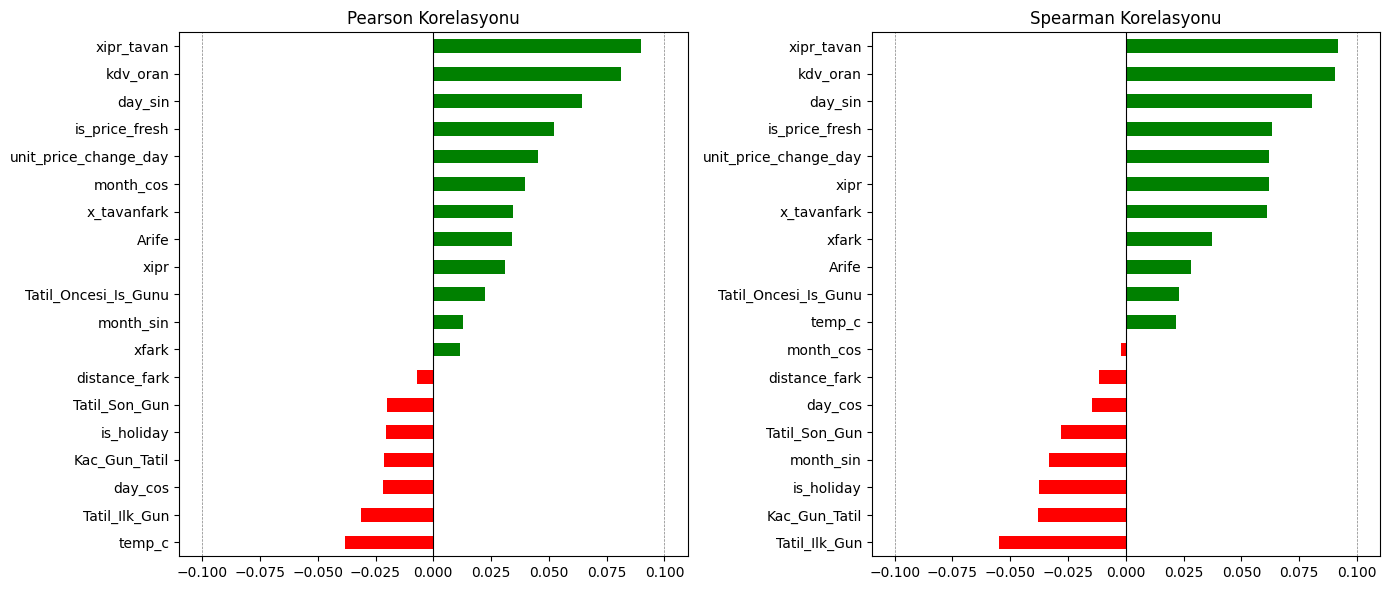

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Analiz edilecek featurelar
features = [
    "xfark", "x_tavanfark", "distance_fark",
    "xipr", "xipr_tavan",
    "unit_price_change_day", "is_price_fresh",
    "temp_c",
    "month_sin", "month_cos", "day_sin", "day_cos",
    "kdv_oran",
    "is_holiday", "Arife", "Tatil_Oncesi_Is_Gunu",
    "Tatil_Ilk_Gun", "Tatil_Son_Gun", "Kac_Gun_Tatil",
]

# ============================================================
# 1. PEARSON KORELASYONU (linear ilişki)
# ============================================================
corr_pearson = df_feat[features + ["total_quantity"]].corr(method="pearson")["total_quantity"].drop("total_quantity").sort_values()

# ============================================================
# 2. SPEARMAN KORELASYONU (non-linear ilişki)
# ============================================================
corr_spearman = df_feat[features + ["total_quantity"]].corr(method="spearman")["total_quantity"].drop("total_quantity").sort_values()

# ============================================================
# 3. SONUÇLARI YAN YANA GÖR
# ============================================================
corr_df = pd.DataFrame({
    "Pearson": corr_pearson,
    "Spearman": corr_spearman
}).sort_values("Spearman", ascending=False)

print(corr_df.round(3))

# ============================================================
# 4. GÖRSEL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_df["Pearson"].sort_values().plot(
    kind="barh", ax=axes[0], color=["red" if x < 0 else "green" for x in corr_df["Pearson"].sort_values()],
    title="Pearson Korelasyonu"
)

corr_df["Spearman"].sort_values().plot(
    kind="barh", ax=axes[1], color=["red" if x < 0 else "green" for x in corr_df["Spearman"].sort_values()],
    title="Spearman Korelasyonu"
)

for ax in axes:
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.axvline(x=0.1, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(x=-0.1, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt

Toplam İlçe Sayısı: 19
Eşikler: min gün = 104, max sıfır oranı = %50

       gun_sayisi  toplam_satis  sifir_gun  ortalama_satis  sifir_orani
count        19.0         19.00      19.00           19.00        19.00
mean       1144.0      51298.63      45.79           44.84         0.04
std           0.0      58529.42     145.64           51.16         0.13
min        1144.0       2563.00       0.00            2.24         0.00
25%        1144.0      15352.00       0.00           13.42         0.00
50%        1144.0      29907.00       1.00           26.14         0.00
75%        1144.0      57903.00      24.50           50.61         0.02
max        1144.0     194917.00     642.00          170.38         0.56

Yeterli & aktif ilçe : 18
Yetersiz gün         : 0 ilçe
Çok fazla sıfır satış: 1 ilçe

Sıfır oranı yüksek ilçeler (> %50):
          gun_sayisi  sifir_gun  sifir_orani  ortalama_satis
IlceKodu                                                    
756             1144        642     

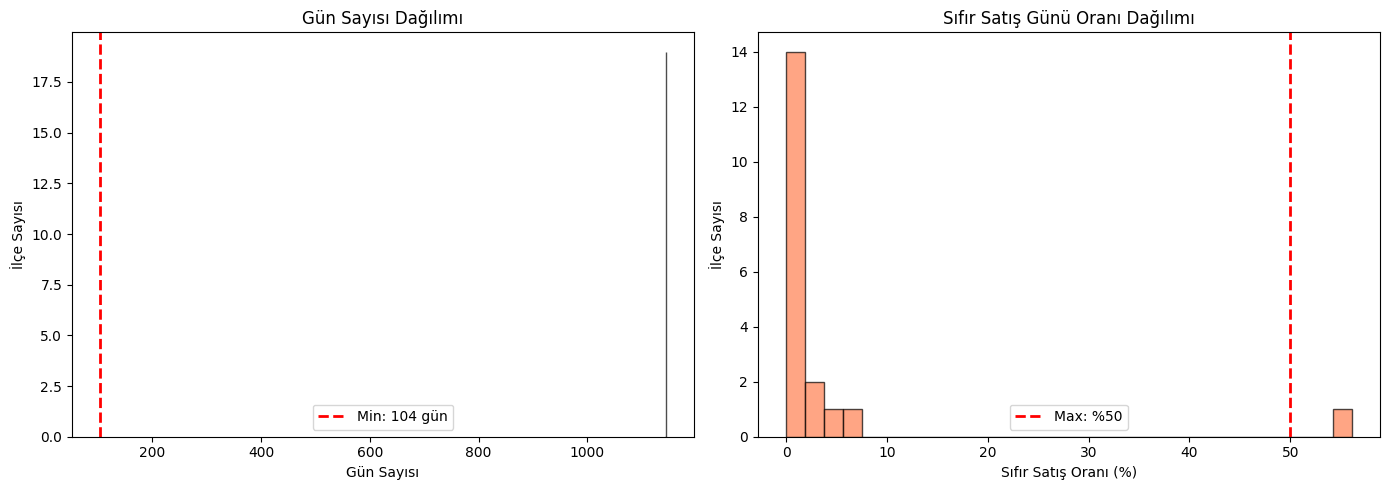

In [36]:
# ============================================================
# İLÇE BAZINDA VERİ YETERLİLİĞİ + SIFIR SATIŞ ANALİZİ
# ============================================================
min_days_required = 90 + 14  # encoder + prediction length
max_zero_ratio = 0.50        # %50'den fazla sıfır satış günü → çıkar

ilce_stats = df_feat.groupby("IlceKodu").agg(
    gun_sayisi=("OrderDay", "nunique"),
    toplam_satis=("total_quantity", "sum"),
    sifir_gun=("total_quantity", lambda x: (x == 0).sum()),
    ortalama_satis=("total_quantity", "mean"),
).assign(
    sifir_orani=lambda d: (d["sifir_gun"] / d["gun_sayisi"]).round(3)
)

print(f"Toplam İlçe Sayısı: {len(ilce_stats)}")
print(f"Eşikler: min gün = {min_days_required}, max sıfır oranı = %{max_zero_ratio*100:.0f}")
print(f"\n{'='*60}")
print(ilce_stats.describe().round(2))

# Filtreleme koşulları
mask_gun   = ilce_stats["gun_sayisi"] >= min_days_required
mask_sifir = ilce_stats["sifir_orani"] <= max_zero_ratio

ilceler_ok        = ilce_stats[mask_gun & mask_sifir].index.tolist()
ilceler_az_gun    = ilce_stats[~mask_gun]
ilceler_cok_sifir = ilce_stats[mask_gun & ~mask_sifir]

print(f"\n{'='*60}")
print(f"Yeterli & aktif ilçe : {len(ilceler_ok)}")
print(f"Yetersiz gün         : {(~mask_gun).sum()} ilçe")
print(f"Çok fazla sıfır satış: {len(ilceler_cok_sifir)} ilçe")

if len(ilceler_cok_sifir) > 0:
    print(f"\nSıfır oranı yüksek ilçeler (> %{max_zero_ratio*100:.0f}):")
    print(ilceler_cok_sifir[["gun_sayisi","sifir_gun","sifir_orani","ortalama_satis"]]
          .sort_values("sifir_orani", ascending=False).to_string())

if len(ilceler_az_gun) > 0:
    print(f"\nYetersiz günlü ilçeler (< {min_days_required} gün):")
    print(ilceler_az_gun[["gun_sayisi","sifir_orani"]].sort_values("gun_sayisi").to_string())

# Görsel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ilce_stats["gun_sayisi"], bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(min_days_required, color="red", linestyle="--", linewidth=2, label=f"Min: {min_days_required} gün")
axes[0].set_xlabel("Gün Sayısı")
axes[0].set_ylabel("İlçe Sayısı")
axes[0].set_title("Gün Sayısı Dağılımı")
axes[0].legend()

axes[1].hist(ilce_stats["sifir_orani"]*100, bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[1].axvline(max_zero_ratio*100, color="red", linestyle="--", linewidth=2, label=f"Max: %{max_zero_ratio*100:.0f}")
axes[1].set_xlabel("Sıfır Satış Oranı (%)")
axes[1].set_ylabel("İlçe Sayısı")
axes[1].set_title("Sıfır Satış Günü Oranı Dağılımı")
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# YETERSİZ VERİLİ + ÇOK SIFIRLI İLÇELERİ ÇIKAR
# ============================================================
rows_before  = len(df_feat)
ilce_before  = df_feat["IlceKodu"].nunique()

df_feat = df_feat[df_feat["IlceKodu"].isin(ilceler_ok)].reset_index(drop=True)

rows_after = len(df_feat)
ilce_after = df_feat["IlceKodu"].nunique()

print(f"Filtreleme öncesi : {rows_before:,} satır, {ilce_before} ilçe")
print(f"Filtreleme sonrası: {rows_after:,} satır, {ilce_after} ilçe")
print(f"Çıkarılan         : {rows_before - rows_after:,} satır, {ilce_before - ilce_after} ilçe")
print(f"  - Yetersiz gün  : {len(ilceler_az_gun)} ilçe")
print(f"  - Çok sıfır     : {len(ilceler_cok_sifir)} ilçe")

Filtreleme öncesi : 21,736 satır, 19 ilçe
Filtreleme sonrası: 20,592 satır, 18 ilçe
Çıkarılan         : 1,144 satır, 1 ilçe
  - Yetersiz gün  : 0 ilçe
  - Çok sıfır     : 1 ilçe


In [38]:
cols = [
    # Index & Grup
    "OrderDay",
    "IlKodu",
    "IlceKodu",

    # Target
    "total_quantity",

    # Known Future Reals
    "xfark",
    "x_tavanfark",
    "xipr",
    "xipr_tavan",
    "unit_price_change_day",
    "is_price_fresh",
    "temp_c",
    "month_sin", "month_cos",
    "day_sin", "day_cos",
    "kdv_oran",

    # Tatil Reals
    "is_holiday", "Arife", "Tatil_Oncesi_Is_Gunu",
    "Tatil_Ilk_Gun", "Tatil_Son_Gun", "Kac_Gun_Tatil",

    # Known Future Categoricals
    "condition_group",
    "Tatil_Turu",
]

df_feat = df_feat[cols].copy()

# Tip düzeltmeleri
df_feat["IlKodu"]   = df_feat["IlKodu"].astype(str)
df_feat["IlceKodu"] = df_feat["IlceKodu"].astype(str)
df_feat["kdv_oran"] = df_feat["kdv_oran"].astype(float)
df_feat["condition_group"] = df_feat["condition_group"].astype(str)
df_feat["Tatil_Turu"] = df_feat["Tatil_Turu"].astype(str)

# Sırala
df_feat = df_feat.sort_values(["IlceKodu", "OrderDay"]).reset_index(drop=True)

df_feat["time_idx"] = (df_feat["OrderDay"] - df_feat["OrderDay"].min()).dt.days

print(df_feat.dtypes)
print(df_feat.shape)
print(df_feat.isnull().sum())

OrderDay                 datetime64[ns]
IlKodu                              str
IlceKodu                            str
total_quantity                  float64
xfark                           float64
x_tavanfark                     float64
xipr                            float64
xipr_tavan                      float64
unit_price_change_day             int64
is_price_fresh                    int64
temp_c                          float64
month_sin                       float64
month_cos                       float64
day_sin                         float64
day_cos                         float64
kdv_oran                        float64
is_holiday                        int64
Arife                             int64
Tatil_Oncesi_Is_Gunu              int64
Tatil_Ilk_Gun                     int64
Tatil_Son_Gun                     int64
Kac_Gun_Tatil                     int64
condition_group                     str
Tatil_Turu                          str
time_idx                          int64


In [39]:
df_feat

,OrderDay,IlKodu,IlceKodu,total_quantity,xfark,x_tavanfark,xipr,xipr_tavan,unit_price_change_day,is_price_fresh,...,kdv_oran,is_holiday,Arife,Tatil_Oncesi_Is_Gunu,Tatil_Ilk_Gun,Tatil_Son_Gun,Kac_Gun_Tatil,condition_group,Tatil_Turu,time_idx
0,2023-01-02,7,701,108.0,0.15,0.15,0.497099,0.697591,0,0,...,8.0,0,0,0,0,0,0,Bulutluluk,Normal_Gun,0
1,2023-01-03,7,701,85.0,0.15,0.15,0.497099,0.697591,0,0,...,8.0,0,0,0,0,0,0,Bulutluluk,Normal_Gun,1
2,2023-01-04,7,701,74.0,0.15,0.15,0.497099,0.697591,0,0,...,8.0,0,0,0,0,0,0,Bulutluluk,Normal_Gun,2
3,2023-01-05,7,701,96.0,0.15,0.15,0.497099,0.697591,0,0,...,8.0,0,0,0,0,0,0,Bulutluluk,Normal_Gun,3
4,2023-01-06,7,701,82.0,0.21,0.21,0.497099,0.697591,1,1,...,8.0,0,0,0,0,0,0,Bulutluluk,Normal_Gun,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587,2026-02-14,7,765,40.0,0.04,0.09,0.887436,1.543346,2,1,...,10.0,0,0,0,0,0,0,Bulutluluk,Normal_Gun,1139
20588,2026-02-15,7,765,16.0,0.04,0.09,0.887436,1.543346,3,1,...,10.0,0,0,0,0,0,0,Yağmur,Normal_Gun,1140
20589,2026-02-16,7,765,63.0,0.04,0.09,0.887436,1.543346,4,1,...,10.0,0,0,0,0,0,0,Yağmur,Normal_Gun,1141
20590,2026-02-17,7,765,43.0,0.04,0.09,0.887436,1.543346,5,1,...,10.0,0,0,0,0,0,0,Yağmur,Normal_Gun,1142


In [40]:
print(df_feat.groupby("IlceKodu")["time_idx"].max().describe())

sample_ilce = df_feat["IlceKodu"].unique()[0]
print(df_feat[df_feat["IlceKodu"] == sample_ilce][["OrderDay","time_idx"]].head(10))

count      18.0
mean     1143.0
std         0.0
min      1143.0
25%      1143.0
50%      1143.0
75%      1143.0
max      1143.0
Name: time_idx, dtype: float64
    OrderDay  time_idx
0 2023-01-02         0
1 2023-01-03         1
2 2023-01-04         2
3 2023-01-05         3
4 2023-01-06         4
5 2023-01-07         5
6 2023-01-08         6
7 2023-01-09         7
8 2023-01-10         8
9 2023-01-11         9


## Model Kurulum

In [41]:
df_feat_model = df_feat[df_feat["OrderDay"] >= "2023-07-01"]

In [49]:
df_feat_model.to_parquet("model_ready_data.parquet", index=False)

### Walk-Forward Deneniyor, scale : robost , 28 gün test 

In [47]:
# ============================================================
# 1. SCALER TANIMI
# ============================================================
robust_cols = [
    "xfark", "x_tavanfark",
    "xipr", "xipr_tavan",
    "temp_c",
    "unit_price_change_day",
    "Kac_Gun_Tatil",
]

standard_cols = [
    "month_sin", "month_cos",
    "day_sin", "day_cos",
    "is_price_fresh",
    "kdv_oran",
    "is_holiday", "Arife", "Tatil_Oncesi_Is_Gunu",
    "Tatil_Ilk_Gun", "Tatil_Son_Gun",
]

scalers = {col: RobustScaler()   for col in robust_cols}
scalers.update({col: StandardScaler() for col in standard_cols})

# ============================================================
# 2. WALK-FORWARD FOLD TANIMI
# ============================================================
total_days  = df_feat["time_idx"].max()
test_days   = 28
n_val_folds = 3
test_start  = total_days - test_days

folds = []

for i in range(n_val_folds):
    val_end   = test_start - (n_val_folds - i - 1) * 14
    val_start = val_end - 14
    train_end = val_start - 1
    folds.append({
        "fold"      : i + 1,
        "train_end" : train_end,
        "val_start" : val_start,
        "val_end"   : val_end - 1,
    })

# Tarihleri yazdır
base_date = df_feat["OrderDay"].min()
for f in folds:
    print(f"Fold {f['fold']}: "
          f"Train → {(base_date + pd.Timedelta(days=f['train_end'])).date()} | "
          f"Val [{(base_date + pd.Timedelta(days=f['val_start'])).date()} → "
          f"{(base_date + pd.Timedelta(days=f['val_end'])).date()}]")
print(f"Test : [{(base_date + pd.Timedelta(days=test_start)).date()} → "
      f"{df_feat['OrderDay'].max().date()}]")


Fold 1: Train → 2025-12-09 | Val [2025-12-10 → 2025-12-23]
Fold 2: Train → 2025-12-23 | Val [2025-12-24 → 2026-01-06]
Fold 3: Train → 2026-01-06 | Val [2026-01-07 → 2026-01-20]
Test : [2026-01-21 → 2026-02-18]


In [48]:
import os
import pickle
from pathlib import Path
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# ============================================================
# 0. KAYIT KLASÖRÜ
# ============================================================
CKPT_DIR = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = CKPT_DIR / "best_model.ckpt"
BEST_META_PATH  = CKPT_DIR / "best_model_meta.pkl"

# Önceki çalıştırmadan kalan en iyi WAPE varsa onu yükle (kaldığın yerden devam)
if BEST_META_PATH.exists():
    with open(BEST_META_PATH, "rb") as f:
        best_meta = pickle.load(f)
    best_wape_overall = best_meta["wape"]
    print(f"📂 Önceki en iyi model bulundu → Fold {best_meta['fold']} | WAPE: %{best_wape_overall:.2f}")
else:
    best_wape_overall = float("inf")
    print("📂 Sıfırdan başlıyor, kayıtlı model yok.")

# ============================================================
# 3. WALK-FORWARD EĞİTİM (güncellenmiş)
# ============================================================
fold_results = []

for fold in folds:
    pl.seed_everything(42 + fold["fold"], workers=True)

    scalers = {col: RobustScaler() for col in robust_cols}
    scalers.update({col: StandardScaler() for col in standard_cols})

    print(f"\n{'='*60}")
    print(f"FOLD {fold['fold']} eğitiliyor...")

    df_tr = df_feat[df_feat["time_idx"] <= fold["train_end"]]
    df_vl = df_feat[df_feat["time_idx"] <= fold["val_end"]]

    tr_dataset = TimeSeriesDataSet(
        df_tr,
        time_idx="time_idx",
        target="total_quantity",
        group_ids=["IlceKodu"],
        max_encoder_length=90,
        max_prediction_length=14,
        static_categoricals=["IlceKodu", "IlKodu"],
        time_varying_known_reals=[
            "xfark", "x_tavanfark",
            "xipr", "xipr_tavan",
            "unit_price_change_day", "is_price_fresh",
            "temp_c",
            "month_sin", "month_cos",
            "day_sin", "day_cos",
            "kdv_oran",
            "is_holiday", "Arife", "Tatil_Oncesi_Is_Gunu",
            "Tatil_Ilk_Gun", "Tatil_Son_Gun", "Kac_Gun_Tatil",
        ],
        time_varying_known_categoricals=["condition_group", "Tatil_Turu"],
        time_varying_unknown_reals=["total_quantity"],
        categorical_encoders={
            "Tatil_Turu": NaNLabelEncoder(add_nan=True),
            "condition_group": NaNLabelEncoder(add_nan=True),
        },
        target_normalizer=GroupNormalizer(groups=["IlceKodu"], transformation="softplus"),
        scalers=scalers,
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
    )

    vl_dataset = TimeSeriesDataSet.from_dataset(
        tr_dataset, df_vl,
        min_prediction_idx=fold["val_start"],
        predict=True,
        stop_randomization=True,
    )

    tr_loader = tr_dataset.to_dataloader(train=True,  batch_size=64, num_workers=0)
    vl_loader = vl_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

    model = TemporalFusionTransformer.from_dataset(
        tr_dataset,
        learning_rate=0.03,
        hidden_size=32,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=16,
        loss=QuantileLoss(),
    )

    # ---------- ⭐ EPOCH SEVİYESİ CHECKPOINT ----------
    fold_ckpt = ModelCheckpoint(
        dirpath=CKPT_DIR,
        filename=f"fold{fold['fold']}-best-{{epoch:02d}}-{{val_loss:.4f}}",
        monitor="val_loss",
        mode="min",
        save_top_k=1,         # sadece o fold'un en iyisini tut
        save_weights_only=False,
        verbose=True,
    )

    early_stop = EarlyStopping(
        monitor="val_loss", patience=10, mode="min", min_delta=1e-4
    )

    trainer = pl.Trainer(
        max_epochs=50,
        accelerator="auto",
        gradient_clip_val=0.1,
        callbacks=[early_stop, fold_ckpt],   # ← checkpoint eklendi
        logger=False,
        enable_progress_bar=True,
    )

    trainer.fit(model, tr_loader, vl_loader)

    # ---------- En iyi epoch'tan tahmin ----------
    best_fold_ckpt_path = fold_ckpt.best_model_path
    print(f"📍 Fold {fold['fold']} en iyi epoch: {best_fold_ckpt_path}")

    best_model = TemporalFusionTransformer.load_from_checkpoint(best_fold_ckpt_path)

    predictions = best_model.predict(
        vl_loader, return_y=True,
        trainer_kwargs=dict(accelerator="auto")
    )
    act = predictions.y[0].cpu().numpy()
    prd = predictions.output.cpu().numpy()

    wape = np.sum(np.abs(act - prd)) / np.sum(np.abs(act)) * 100
    mae  = np.mean(np.abs(act - prd))

    fold_results.append({
        "fold": fold["fold"],
        "wape": round(wape, 2),
        "mae" : round(mae, 2),
        "ckpt": best_fold_ckpt_path,
    })
    print(f"Fold {fold['fold']} → WAPE: %{wape:.1f} | MAE: {mae:.1f}")

    # ---------- ⭐ FOLD SEVİYESİ: GENEL EN İYİYİ GÜNCELLE ----------
    if wape < best_wape_overall:
        print(f"🏆 YENİ EN İYİ! (önceki: %{best_wape_overall:.2f} → yeni: %{wape:.2f})")
        best_wape_overall = wape

        # Checkpoint'i kalıcı isimle kopyala
        import shutil
        shutil.copy(best_fold_ckpt_path, BEST_MODEL_PATH)

        # Dataset parametrelerini de kaydet (simülasyonda lazım)
        with open(BEST_META_PATH, "wb") as f:
            pickle.dump({
                "fold": fold["fold"],
                "wape": wape,
                "mae" : mae,
                "dataset_params": tr_dataset.get_parameters(),
            }, f)
        print(f"💾 Kaydedildi → {BEST_MODEL_PATH}")
    else:
        print(f"   (Genel en iyi hâlâ %{best_wape_overall:.2f}, kayıt güncellenmedi)")

# ============================================================
# 4. ÖZET
# ============================================================
print(f"\n{'='*60}")
print(f"{'Fold':<8} {'WAPE':>8} {'MAE':>8}")
print(f"{'-'*25}")
for r in fold_results:
    print(f"{r['fold']:<8} %{r['wape']:>7} {r['mae']:>8}")
print(f"{'-'*25}")
print(f"{'Ort':<8} %{np.mean([r['wape'] for r in fold_results]):>7.1f} "
      f"{np.mean([r['mae'] for r in fold_results]):>8.1f}")
print(f"\n🏆 GENEL EN İYİ: %{best_wape_overall:.2f} → {BEST_MODEL_PATH}")

Seed set to 43
/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/proj

📂 Sıfırdan başlıyor, kayıtlı model yok.

FOLD 1 eğitiliyor...



   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 166    | train | 0    
3  | prescalers                         | ModuleDict                      | 736    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 6.1 K  | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 46.2 K | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 43.5 K | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 4.3 K  | train | 0    
8  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Epoch 30, global step 8432: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 31, global step 8704: 'val_loss' was not in top 1

Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [45]:
# ============================================================
# 1. SCALER TANIMI
# ============================================================
robust_cols = [
    "xfark", "x_tavanfark",
    "xipr", "xipr_tavan",
    "temp_c",
    "unit_price_change_day",
    "Kac_Gun_Tatil",
]

standard_cols = [
    "month_sin", "month_cos",
    "day_sin", "day_cos",
    "is_price_fresh",
    "kdv_oran",
    "is_holiday", "Arife", "Tatil_Oncesi_Is_Gunu",
    "Tatil_Ilk_Gun", "Tatil_Son_Gun",
]

scalers = {col: RobustScaler()   for col in robust_cols}
scalers.update({col: StandardScaler() for col in standard_cols})

# ============================================================
# 2. WALK-FORWARD FOLD TANIMI
# ============================================================
total_days  = df_feat["time_idx"].max()
test_days   = 28
n_val_folds = 3
test_start  = total_days - test_days

folds = []

for i in range(n_val_folds):
    val_end   = test_start - (n_val_folds - i - 1) * 14
    val_start = val_end - 14
    train_end = val_start - 1
    folds.append({
        "fold"      : i + 1,
        "train_end" : train_end,
        "val_start" : val_start,
        "val_end"   : val_end - 1,
    })

# Tarihleri yazdır
base_date = df_feat["OrderDay"].min()
for f in folds:
    print(f"Fold {f['fold']}: "
          f"Train → {(base_date + pd.Timedelta(days=f['train_end'])).date()} | "
          f"Val [{(base_date + pd.Timedelta(days=f['val_start'])).date()} → "
          f"{(base_date + pd.Timedelta(days=f['val_end'])).date()}]")
print(f"Test : [{(base_date + pd.Timedelta(days=test_start)).date()} → "
      f"{df_feat['OrderDay'].max().date()}]")

# ============================================================
# 3. WALK-FORWARD EĞİTİM
# ============================================================
fold_results = []

for fold in folds:
    pl.seed_everything(42 + fold["fold"], workers=True)
    
    scalers = {col: RobustScaler() for col in robust_cols}
    scalers.update({col: StandardScaler() for col in standard_cols})
    
    df_tr = df_feat[df_feat["time_idx"] <= fold["train_end"]]

    print(f"\n{'='*60}")
    print(f"FOLD {fold['fold']} eğitiliyor...")

    df_tr = df_feat[df_feat["time_idx"] <= fold["train_end"]]
    df_vl = df_feat[df_feat["time_idx"] <= fold["val_end"]]

    tr_dataset = TimeSeriesDataSet(
        df_tr,
        time_idx="time_idx",
        target="total_quantity",
        group_ids=["IlceKodu"],
        max_encoder_length=90,
        max_prediction_length=14,

        static_categoricals=["IlceKodu", "IlKodu"],

        time_varying_known_reals=[
            "xfark", "x_tavanfark",
            "xipr", "xipr_tavan",
            "unit_price_change_day", "is_price_fresh",
            "temp_c",
            "month_sin", "month_cos",
            "day_sin", "day_cos",
            "kdv_oran",
            "is_holiday", "Arife", "Tatil_Oncesi_Is_Gunu",
            "Tatil_Ilk_Gun", "Tatil_Son_Gun", "Kac_Gun_Tatil",
        ],
        time_varying_known_categoricals=["condition_group", "Tatil_Turu"],
        time_varying_unknown_reals=["total_quantity"],

        categorical_encoders={
            "Tatil_Turu": NaNLabelEncoder(add_nan=True),
            "condition_group": NaNLabelEncoder(add_nan=True),
        },

        target_normalizer=GroupNormalizer(
            groups=["IlceKodu"],
            transformation="softplus"
        ),
        scalers=scalers,

        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
    )

    vl_dataset = TimeSeriesDataSet.from_dataset(
        tr_dataset, df_vl,
        min_prediction_idx=fold["val_start"],
        predict=True,
        stop_randomization=True,
    )

    tr_loader = tr_dataset.to_dataloader(train=True,  batch_size=64, num_workers=0)
    vl_loader = vl_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

    model = TemporalFusionTransformer.from_dataset(
        tr_dataset,
        learning_rate=0.03,
        hidden_size=32,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=16,
        loss=QuantileLoss(),
    )

    trainer = pl.Trainer(
        max_epochs=50,
        accelerator="auto",
        gradient_clip_val=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=10, mode="min", min_delta=1e-4)],
        logger=False,
        enable_progress_bar=True,
    )

    trainer.fit(model, tr_loader, vl_loader)

    # Tahmin
    predictions = model.predict(
        vl_loader, return_y=True,
        trainer_kwargs=dict(accelerator="auto")
    )

    act = predictions.y[0].cpu().numpy()
    prd = predictions.output.cpu().numpy()

    # Metrikler
    wape = np.sum(np.abs(act - prd)) / np.sum(np.abs(act)) * 100
    mae  = np.mean(np.abs(act - prd))

    fold_results.append({
        "fold" : fold["fold"],
        "wape" : round(wape, 2),
        "mae"  : round(mae, 2),
        "model": model,
    })
    print(f"Fold {fold['fold']} → WAPE: %{wape:.1f} | MAE: {mae:.1f}")

# ============================================================
# 4. ÖZET
# ============================================================
print(f"\n{'='*60}")
print(f"{'Fold':<8} {'WAPE':>8} {'MAE':>8}")
print(f"{'-'*25}")
for r in fold_results:
    print(f"{r['fold']:<8} %{r['wape']:>7} {r['mae']:>8}")
print(f"{'-'*25}")
print(f"{'Ort':<8} %{np.mean([r['wape'] for r in fold_results]):>7.1f} "
      f"{np.mean([r['mae'] for r in fold_results]):>8.1f}")
print(f"{'Std':<8}  {np.std([r['wape'] for r in fold_results]):>7.1f} "
      f"{np.std([r['mae'] for r in fold_results]):>8.1f}")

Seed set to 43
/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/proj

Fold 1: Train → 2025-12-09 | Val [2025-12-10 → 2025-12-23]
Fold 2: Train → 2025-12-23 | Val [2025-12-24 → 2026-01-06]
Fold 3: Train → 2026-01-06 | Val [2026-01-07 → 2026-01-20]
Test : [2026-01-21 → 2026-02-18]

FOLD 1 eğitiliyor...


/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/testai/Desktop/price_analytics_cylinder/price_analytics_cylinder/T-pl-gaz-Analiz/price_analytics_cylindirc/checkpoints exists and is not empty.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 166    | train | 0    
3  | prescalers                         | ModuleDict                      | 736    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 6.1 K  | train | 0    
5  | encoder_var

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/envs/feyza-ava/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Fold 3 → WAPE: %18.4 | MAE: 10.0

Fold         WAPE      MAE
-------------------------
1        %12.649999618530273 7.190000057220459
2        %21.059999465942383 12.800000190734863
3        %18.43000030517578 10.010000228881836
-------------------------
Ort      %   17.4     10.0
Std           3.5      2.3


In [43]:
# ============================================================
# NAIVE BASELINE: Geçen hafta aynı gün
# ============================================================
test_start = df_feat["time_idx"].max() - 28

# Test verisi
test_data = df_feat[df_feat["time_idx"] >= test_start].copy()

# Her ilçe için 7 gün önceki değer
test_data = test_data.sort_values(["IlceKodu", "time_idx"])
test_data["naive_pred"] = test_data.groupby("IlceKodu")["total_quantity"].shift(7)

# NaN olanları çıkar (ilk 7 gün için tahmin yok)
test_clean = test_data.dropna(subset=["naive_pred"])

# WAPE ve MAE
naive_wape = (test_clean["total_quantity"] - test_clean["naive_pred"]).abs().sum() / \
             test_clean["total_quantity"].abs().sum() * 100
naive_mae = (test_clean["total_quantity"] - test_clean["naive_pred"]).abs().mean()

print(f"NAIVE BASELINE (geçen hafta aynı gün)")
print(f"WAPE: %{naive_wape:.1f}")
print(f"MAE : {naive_mae:.2f}")
print(f"\nKıyaslama:")
print(f"TFT modelin   → WAPE: %17.4 | MAE: 10.0")
print(f"Naive baseline → WAPE: %{naive_wape:.1f} | MAE: {naive_mae:.2f}")

NAIVE BASELINE (geçen hafta aynı gün)
WAPE: %22.8
MAE : 14.31

Kıyaslama:
TFT modelin   → WAPE: %17.4 | MAE: 10.0
Naive baseline → WAPE: %22.8 | MAE: 14.31


In [44]:
# En iyi fold modeli
best_model = fold_results[0]["model"]  # Fold 1

# Test datasetini oluştur
test_dataset = TimeSeriesDataSet.from_dataset(
    tr_dataset, df_feat,
    min_prediction_idx=test_start,
    predict=True,
    stop_randomization=True,
)
test_loader = test_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

# Tahmin
test_predictions = best_model.predict(
    test_loader, return_y=True,
    trainer_kwargs=dict(accelerator="auto")
)

act = test_predictions.y[0].cpu().numpy()
prd = test_predictions.output.cpu().numpy()

test_wape = np.sum(np.abs(act - prd)) / np.sum(np.abs(act)) * 100
test_mae = np.mean(np.abs(act - prd))

print(f"TEST SETİ SONUÇLARI")
print(f"WAPE: %{test_wape:.1f}")
print(f"MAE : {test_mae:.2f}")

NameError: name 'fold_results' is not defined

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Tahminleri index ile birlikte al
test_predictions = best_model.predict(
    test_loader, 
    return_y=True,
    return_index=True,
    trainer_kwargs=dict(accelerator="auto")
)

actuals = test_predictions.y[0].cpu().numpy()
preds = test_predictions.output.cpu().numpy()
index = test_predictions.index
ilce_codes = index["IlceKodu"].values

# Her ilçe için WAPE hesapla
ilce_wape = []
for i, ilce in enumerate(ilce_codes):
    if np.sum(np.abs(actuals[i])) > 0:
        wape = np.sum(np.abs(actuals[i] - preds[i])) / np.sum(np.abs(actuals[i])) * 100
    else:
        wape = 0
    ilce_wape.append((ilce, i, wape))

# Performansa göre sırala (en iyiden en kötüye)
ilce_wape.sort(key=lambda x: x[2])

# Grid yapısı
n_ilce = len(ilce_codes)
n_cols = 4
n_rows = (n_ilce + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = axes.flatten() if n_ilce > 1 else [axes]

for plot_idx, (ilce, data_idx, wape) in enumerate(ilce_wape):
    ax = axes[plot_idx]
    days = np.arange(len(actuals[data_idx]))
    
    ax.plot(days, actuals[data_idx], 'o-', label='Gerçek', 
            color='steelblue', linewidth=2, markersize=6)
    ax.plot(days, preds[data_idx], 's--', label='Tahmin', 
            color='coral', linewidth=2, markersize=6)
    
    # Renk kodu: yeşil=iyi, sarı=orta, kırmızı=kötü
    color = 'green' if wape < 15 else ('orange' if wape < 25 else 'red')
    ax.set_title(f"İlçe {ilce} | WAPE: %{wape:.1f}", 
                 fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Tahmin Günü')
    ax.set_ylabel('Toplam Tüp')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)

# Boş subplot'ları sil
for j in range(n_ilce, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Test Seti — İlçe Bazlı Tahminler (en iyiden en kötüye)', 
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('ilce_tahminleri.png', dpi=120, bbox_inches='tight')
plt.show()

# Özet tablo
print("\n" + "="*50)
print("İLÇE BAZLI PERFORMANS")
print("="*50)
print(f"{'İlçe':<15} {'WAPE':>10}")
print("-"*30)
for ilce, _, wape in ilce_wape:
    print(f"{str(ilce):<15} %{wape:>8.1f}")

NameError: name 'best_model' is not defined